In [95]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special 

# 6.1 Spontaneous Magnetization

In [3]:
# Reuse definitions from exercise 5

def H2d(J,x):
    return -J*(np.roll(x,-1, axis=1)*x + np.roll(x,1, axis=1)*x +np.roll(x,-1, axis=0)*x + np.roll(x,1, axis=0)*x).sum()

def delH2d(J,sigma,x):
    a = x[0]
    b = x[1]
    delH = 0
    if a == len(sigma)-1:
        delH = sigma[a,b]*sigma[a-1,b] + sigma[a,b]*sigma[0,b]
    else:
        delH = sigma[a,b]*sigma[a-1,b] + sigma[a,b]*sigma[a+1,b]
    if b == len(sigma.T)-1:
        delH = delH + sigma[a,b]*sigma[a,b-1] + sigma[a,b]*sigma[a,0]
    else:
        delH = delH + sigma[a,b]*sigma[a,b-1] + sigma[a,b]*sigma[a,b+1]
        
    return 2*J*delH

def MC_right(J,start,steps):

    current = start
    m = np.zeros(steps)
    m_abs = np.zeros(steps)
    eps = np.zeros(steps)

    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(len(start), 2)

        if np.random.uniform(low=0, high=1) < np.exp(-delH2d(J,current,x)): # accepting condition
            # if accepted flip a spin
            new = current
            new[x[0],x[1]] = -current[x[0],x[1]]

        else:
            # else keep current spinconfiguration
            new = current
        current = new
        #calculate M/N
        
        m[s] = current.sum()/(len(start))**2
        m_abs[s] = np.abs(m[s])
        eps[s] = H2d(J,current)/(2*(len(start))**2)

    return m, m_abs, eps

In [37]:

def checkerboard(dim):
    x = np.ones((dim,dim))
    i = np.arange(len(x))%2
    j = np.arange(len(x.T))%2
    for q in range(len(j)):
        for h in range(len(i)):  
            if i[h] == j[q]:
                x[h,q]=-1
    return x

In [46]:
Jc = 0.5*np.log(1+np.sqrt(2))

J = np.array([0.1, 0.2, Jc, 0.7, 0.8])

start_4 = checkerboard(4)
m_abs_4 = [MC_right(J[c],start_4,10000)[1] for c in range(len(J))]

[array([0.125, 0.125, 0.25 , ..., 0.125, 0.   , 0.125]), array([0.25 , 0.375, 0.5  , ..., 0.5  , 0.5  , 0.375]), array([0.375, 0.5  , 0.5  , ..., 0.625, 0.625, 0.75 ]), array([0.75 , 0.875, 0.875, ..., 1.   , 1.   , 1.   ]), array([1., 1., 1., ..., 1., 1., 1.])]


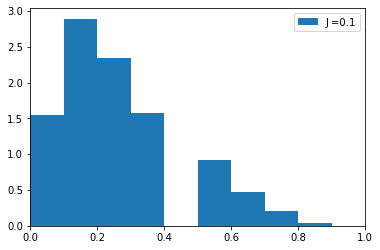

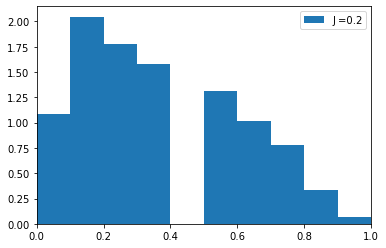

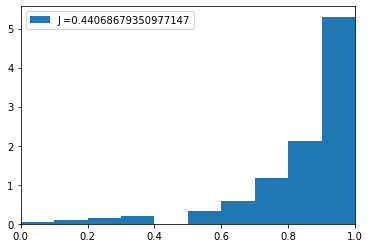

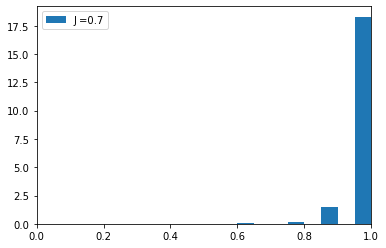

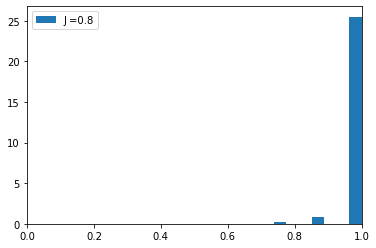

In [62]:
for c in range(len(J)):
    plt.hist(m_abs_4[c], label=f"J ={J[c]}",density = True)
    plt.legend()
    plt.xlim(0,1)
    plt.show()

In [54]:
start_8 = checkerboard(8)
m_abs_8 = [MC_right(J[c],start_8,10000)[1] for c in range(len(J))]

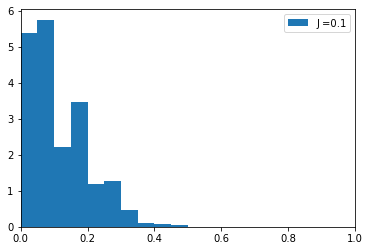

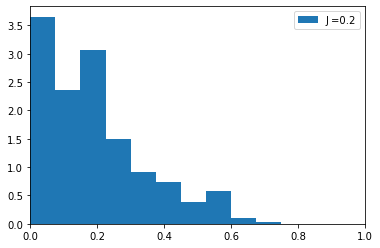

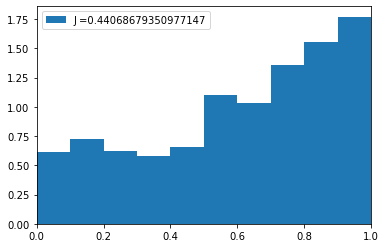

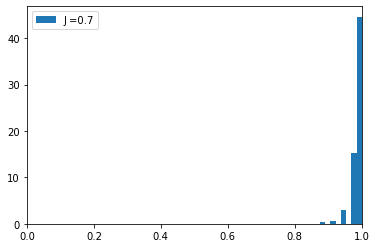

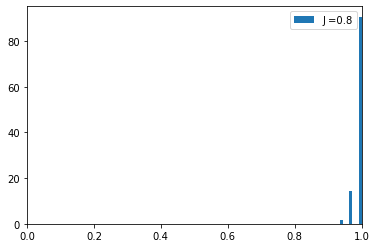

In [61]:
for c in range(len(J)):
    plt.hist(m_abs_8[c], label=f"J ={J[c]}",density = True)
    plt.legend()
    plt.xlim(0,1)
    plt.show()

In [58]:
start_12 = checkerboard(12)
m_abs_12 = [MC_right(J[c],start_12,10000)[1] for c in range(len(J))]

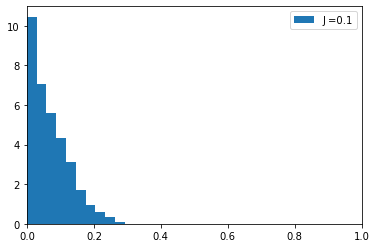

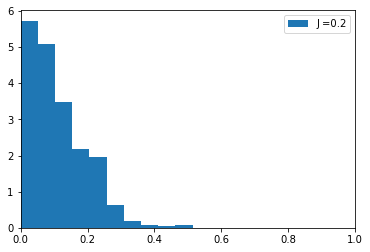

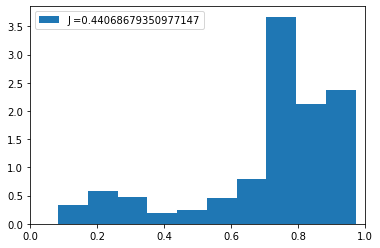

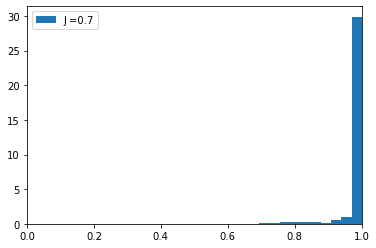

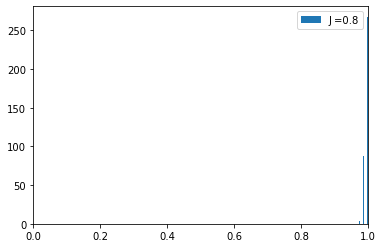

In [60]:
for c in range(len(J)):
    plt.hist(m_abs_12[c], label=f"J ={J[c]}",density = True)
    plt.legend()
    plt.xlim(0,1)
    plt.show()

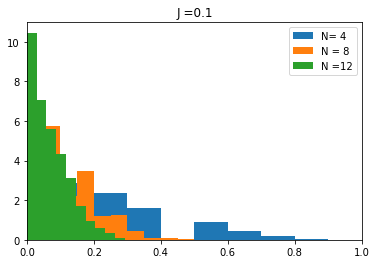

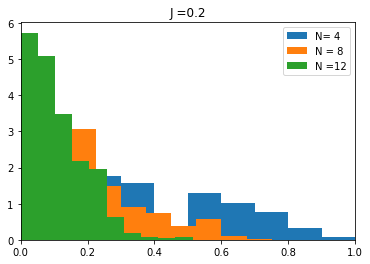

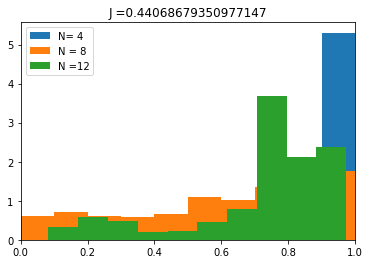

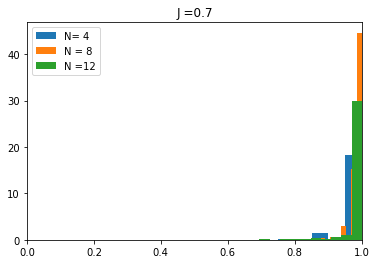

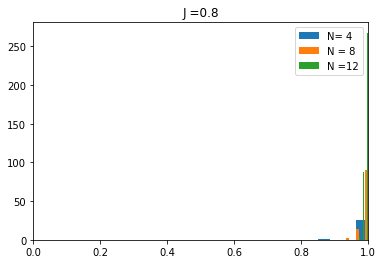

In [64]:
for c in range(len(J)):
    plt.hist(m_abs_4[c], label=f"N= 4",density = True)
    plt.hist(m_abs_8[c], label=f"N = 8",density = True)
    plt.hist(m_abs_12[c], label=f"N =12",density = True)
    plt.title(f"J ={J[c]}")
    plt.legend()
    plt.xlim(0,1)
    plt.show()

# 6.2 Scanning $J$

In [96]:
def m(J):
    m = np.zeros(len(J))
    for t in range(len(J)):
        Jc = 0.5*np.log(1+np.sqrt(2))
        if J[t] > Jc:
            m[t] = (1- 1/(np.sinh(2*J[t])**4))**(1/8)
        else:
            m[t] = 0
    return m

def coth(x):
    return np.cosh(x)/np.sinh(x)

def sech(x):
    return 1/np.cosh(x)

def epsilon(J):
    return -J*coth(2*J)*(1+ 2/np.pi*(2*np.tanh(2*J)**2-1)*scipy.special.ellipk(4*sech(2*J)**2*np.tanh(2*J)**2))

In [75]:
J_2 = np.arange(1,4.1,0.1)
JM = np.linspace(1,4,1000)
steps = 2000
m_abs_4_mean = [MC_right(1/J_2[c], start_4,steps)[1].mean() for c in range(len(J_2))]
m_abs_4_uncert = [MC_right(1/J_2[c], start_4,steps)[1].std() for c in range(len(J_2))]
m_abs_8_mean = [MC_right(1/J_2[c], start_8,steps)[1].mean() for c in range(len(J_2))]
m_abs_8_uncert = [MC_right(1/J_2[c], start_8,steps)[1].std() for c in range(len(J_2))]
m_abs_12_mean = [MC_right(1/J_2[c], start_12,steps)[1].mean() for c in range(len(J_2))]
m_abs_12_uncert = [MC_right(1/J_2[c], start_12,steps)[1].std() for c in range(len(J_2))]

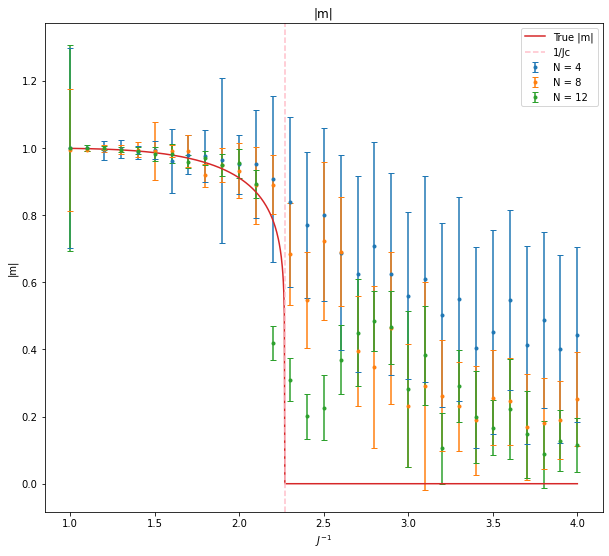

In [105]:

fig,ax =plt.subplots(figsize=(10,9))
ax.errorbar(J_2, m_abs_4_mean, yerr = m_abs_4_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 4")
ax.errorbar(J_2, m_abs_8_mean, yerr = m_abs_8_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 8")
ax.errorbar(J_2, m_abs_12_mean, yerr = m_abs_12_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 12")
ax.plot(JM,m(1/JM), label = "True |m|")
ax.axvline(1/Jc, linestyle = '--', color = 'pink', label = '1/Jc')
ax.set_title('|m|')
ax.legend()
ax.set_xlabel('$J^{-1}$')
ax.set_ylabel('|m|')
plt.show()

In [92]:

eps_M = np.linspace(1,4,1000)
steps = 2000
eps_4_mean = [MC_right(1/J_2[c], start_4,steps)[2].mean() for c in range(len(J_2))]
eps__4_uncert = [MC_right(1/J_2[c], start_4,steps)[2].std() for c in range(len(J_2))]
eps_8_mean = [MC_right(1/J_2[c], start_8,steps)[2].mean() for c in range(len(J_2))]
eps_8_uncert = [MC_right(1/J_2[c], start_8,steps)[2].std() for c in range(len(J_2))]
eps_12_mean = [MC_right(1/J_2[c], start_12,steps)[2].mean() for c in range(len(J_2))]
eps_12_uncert = [MC_right(1/J_2[c], start_12,steps)[2].std() for c in range(len(J_2))]

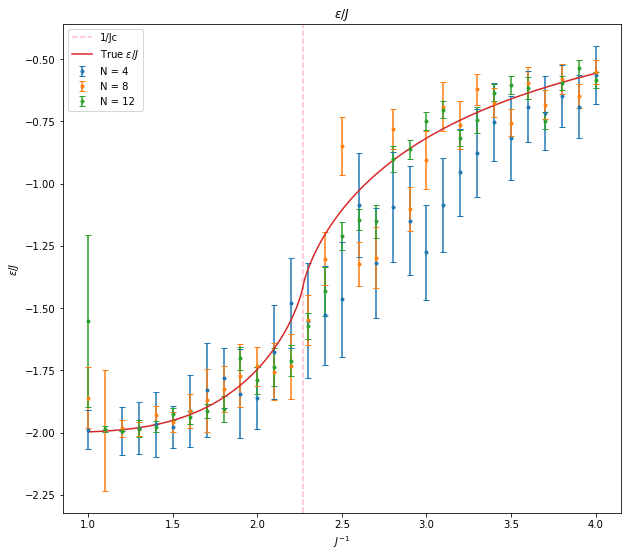

In [106]:
fig,ax =plt.subplots(figsize=(10,9))
ax.errorbar(J_2, eps_4_mean*J_2, yerr = eps__4_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 4")
ax.errorbar(J_2, eps_8_mean*J_2, yerr = eps_8_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 8")
ax.errorbar(J_2, eps_12_mean*J_2, yerr = eps_12_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 12")
ax.axvline(1/Jc, linestyle = '--', color = 'pink', label = '1/Jc')
ax.plot(JM,epsilon(1/JM)*JM, label = "True $\epsilon/J$")
ax.set_title('$\epsilon/J$')
ax.legend()
ax.set_xlabel('$J^{-1}$')
ax.set_ylabel('$\epsilon/J$')
plt.show()

# 6.3 The Spin-Spin Correlation Function

What value should $C(0)$ take : $C(0) = \frac{1}{\Lambda}\sum{C_{x,x}} = \frac{1}{\Lambda}\sum{\frac{1}{Z} \sum_\sigma e^{-\beta H} \sigma_x \sigma_x} = \frac{1}{\Lambda}\sum{\frac{1}{Z} \sum_\sigma e^{-\beta H}} =\frac{1}{\Lambda} \Lambda =1 $


In [215]:
# AB hier bin ich mir unsicher


def auto(timeseries):
    steps = len(timeseries)
    mean = timeseries.mean()
    series = timeseries-mean
    C = np.zeros_like(timeseries)
    C[0,0] = (series *series).mean()
    print(C[0])
    for dt in range(1, steps-1):
        C[dt,dt] = (series[:-dt,:-dt]*series[dt:,dt:]).mean()
    return C / C[0,0]


def fft(timeseries):
    steps = len(timeseries)
    #mean = timeseries.mean()
    series = timeseries
    Cvert = np.fft.ifft(np.fft.fft(series) * np.fft.ifft(series)).real
    Choriz = np.fft.ifft(np.fft.fft(series.T) * np.fft.ifft(series.T)).real
    C = Cvert.mean(axis=0) + Choriz.mean(axis=0)
    return C / C[0]
print(fft(checkerboard(4)))
print(fft(q))

[ 1. -1.  1. -1.]
[1.         0.64285714]


In [265]:
def MC_fft(J,start,steps):

    current = start
    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(len(start), 2)

        if np.random.uniform(low=0, high=1) < np.exp(-delH2d(J,current,x)): # accepting condition
            # if accepted flip a spin
            new = current
            new[x[0],x[1]] = -current[x[0],x[1]]

        else:
            # else keep current spinconfiguration
            new = current
        current = new
        
        # Calcuate for each current C
    C = fft(current)

    return C

In [270]:
steps =2000
C1_4 = MC_fft(1,start_4,steps)
C2_4 = MC_fft(1/2,start_4,steps)
C3_4 = MC_fft(1/3,start_4,steps)
C4_4 = MC_fft(1/4,start_4,steps)
C1_8 = MC_fft(1,start_8,steps)
C2_8 = MC_fft(1/2,start_8,steps)
C3_8 = MC_fft(1/3,start_8,steps)
C4_8 = MC_fft(1/4,start_8,steps)
C1_12 = MC_fft(1,start_12,steps)
C2_12 = MC_fft(1/2,start_12,steps)
C3_12 = MC_fft(1/3,start_12,steps)
C4_12 = MC_fft(1/4,start_12,steps)


[1.   0.25 0.5  0.25]


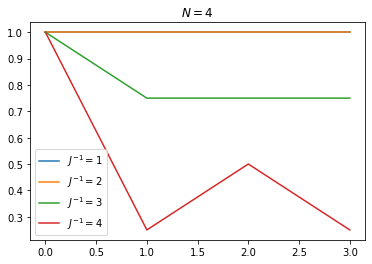

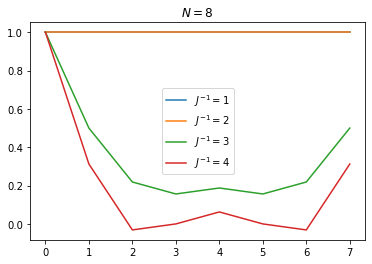

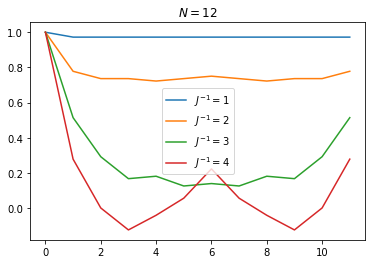

In [271]:

plt.plot(C1_4, label = '$J^{-1} =1$')
plt.plot(C2_4, label = '$J^{-1} =2$')
plt.plot(C3_4, label = '$J^{-1} =3$')
plt.plot(C4_4, label = '$J^{-1} =4$')
plt.title('$N = 4$')
plt.legend()
plt.show()
plt.plot(C1_8, label = '$J^{-1} =1$')
plt.plot(C2_8, label = '$J^{-1} =2$')
plt.plot(C3_8, label = '$J^{-1} =3$')
plt.plot(C4_8, label = '$J^{-1} =4$')
plt.title('$N = 8$')
plt.legend()
plt.show()
plt.plot(C1_12, label = '$J^{-1} =1$')
plt.plot(C2_12, label = '$J^{-1} =2$')
plt.plot(C3_12, label = '$J^{-1} =3$')
plt.plot(C4_12, label = '$J^{-1} =4$')
plt.title('$N = 12$')
plt.legend()
plt.show()

In [318]:
#Ableitung C(x)=C(x+dx)-C(x)/dx
def xi_1(C,dx):
    if dx>0:
        dC = (np.log(C[dx])-np.log(C[0]))/dx
        if dC==0:
            return np.inf
        else:
            return -1/dC
    else:
        return 0

def xi_2(C,x0,h):
    return -C[x0]*h/(C[x0+h]-C[x0])

def exp_pure(x):
    return np.exp(-x/23) 

s = np.linspace(0,100,100)
Cexp = np.zeros(len(s))
xi_test = np.zeros(len(s))
for x in range(len(s)-1):
    Cexp[x] =  exp_pure(x)
    
#xi_2(Cexp,0,1)
xi_1(Cexp,50)

23.0

In [321]:
xi_4=[xi_1(C1_4,2),
xi_1(C2_4,2),
xi_1(C3_4,2),
xi_1(C4_4,2)]
xi_8=[xi_1(C1_8,4),
xi_1(C2_8,4),
xi_1(C3_8,4),
xi_1(C4_8,4)]
xi_12=[xi_1(C1_12,6),
xi_1(C2_12,6),
xi_1(C3_12,6),
xi_1(C4_12,6)]
print(xi_4,xi_8,xi_12)

[inf, inf, 6.952118993564414, 2.8853900817779268] [inf, inf, 2.389519899910072, 1.4426950408889632] [212.98591474781603, 20.856356980693246, 3.0393889211785097, 3.9891564176550673]


In [348]:
def normalized_autocorrelation_function(timeseries, mean=None, until=None, fast=False):
    steps = len(timeseries)
    if mean is None:
        mean = timeseries.mean()
    series = timeseries-mean

    if fast:
        C = np.fft.ifft(np.fft.fft(series) * np.fft.ifft(series)).real
        # You showed why in exercise 4.3
    else:
        C = np.zeros_like(timeseries)
        C[0] = (series * series).mean()
        for dt in range(1, steps-1):
            C[dt] = (series[:-dt]*series[dt:]).mean()

    if until is None:
        return C / C[0]
    else:
        return C[:until] / C[0]

def autocorrelation_time(timeseries):
    gamma = normalized_autocorrelation_function(timeseries, mean = 0)
    for x in range(len(gamma)):
        stop = len(gamma)
        if gamma[0] >0:

            if gamma[x]<0:
                stop= x-1
                break

        else:
            if gamma[x]>0:
                stop= x-1
                break   
    #if stop < len(gamma):
    tau = 1/2 +gamma[:stop].sum()
   # else:
        #tau = np.inf
    return tau

In [349]:
steps = 2000
J_3 =[1,2,3,4]
tau_4 = [autocorrelation_time(MC_right(1/J_3[c], start_4,steps)[0]) for c in range(len(J_3))]
tau_8 = [autocorrelation_time(MC_right(1/J_3[c], start_8,steps)[0]) for c in range(len(J_3))]
tau_12 = [autocorrelation_time(MC_right(1/J_3[c], start_12,steps)[0]) for c in range(len(J_3))]
print(tau_4,tau_8,tau_12)

[1992.9081919906123, 1957.6007740556195, 658.3245706014376, 35.495068531942565] [1780.8151730761865, 2031.8345377605228, 1298.7671725657838, 416.4279280162299] [150.1166112549954, 1219.2096529939452, 1851.4825445975468, 374.0918259309386]


[1992.9081919906123, 1957.6007740556195, 658.3245706014376, 35.495068531942565] [inf, inf, 6.952118993564414, 2.8853900817779268]


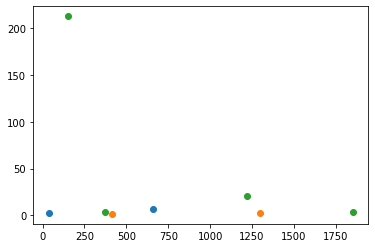

In [354]:
print(tau_4,xi_4)
plt.scatter(tau_4,xi_4)
plt.scatter(tau_8,xi_8)
plt.scatter(tau_12,xi_12)